# HW9 - Cross-Validation & Hyperparameter Tuning

Dataset: `data/Social_Network_Ads.csv`

Submitted by Sruthilaya Umasankari Soma Shanmuga Sundaram

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, KFold,
    RepeatedStratifiedKFold, RepeatedKFold, GridSearchCV,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    classification_report,
)

DATA_PATH = "data/Social_Network_Ads.csv"

np.random.seed(0)


## Q1: Data Pipeline & Baseline Model

In [2]:
def load_and_prepare(filepath, test_size=0.25, random_state=0):
    """Loading Social_Network_Ads data, split, and scale features"""
    df = pd.read_csv(filepath)

    feature_cols = df.columns[:-1]
    target_col = df.columns[-1]

    X = df[feature_cols].to_numpy()
    y = df[target_col].to_numpy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}\n")

    for name, y_split in [("Train", y_train), ("Test", y_test)]:
        counts = pd.Series(y_split).value_counts().sort_index()
        pct = (counts / counts.sum() * 100).round(1)
        print(f"{name} class distribution:")
        for cls in counts.index:
            print(f"  class {cls}: count={counts[cls]}, pct={pct[cls]}%")

    print("\nFeature stats before scaling (train):")
    for i, col in enumerate(feature_cols):
        print(f"  {col}: mean={X_train[:, i].mean():.2f}, std={X_train[:, i].std():.2f}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("\nFeature stats after scaling (train):")
    for i, col in enumerate(feature_cols):
        print(f"  {col}: mean={X_train_scaled[:, i].mean():.2f}, std={X_train_scaled[:, i].std():.2f}")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


X_train, X_test, y_train, y_test, scaler = load_and_prepare(DATA_PATH)


X_train shape: (300, 2), X_test shape: (100, 2)
y_train shape: (300,), y_test shape: (100,)

Train class distribution:
  class 0: count=193, pct=64.3%
  class 1: count=107, pct=35.7%
Test class distribution:
  class 0: count=64, pct=64.0%
  class 1: count=36, pct=36.0%

Feature stats before scaling (train):
  Age: mean=37.69, std=10.54
  EstimatedSalary: mean=69486.67, std=34103.13

Feature stats after scaling (train):
  Age: mean=-0.00, std=1.00
  EstimatedSalary: mean=-0.00, std=1.00


In [3]:
def train_and_evaluate(X_train, X_test, y_train, y_test, **kwargs):
    """Training a RandomForestClassifier and creating a report confusion matrix, accuracy, precision, recall, F1."""
    kwargs.setdefault("random_state", 0)
    model = RandomForestClassifier(**kwargs)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Confusion matrix:\n{cm}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")

    return model, acc


rf_model, rf_acc = train_and_evaluate(X_train, X_test, y_train, y_test, n_estimators=100)


Confusion matrix:
[[56  8]
 [ 6 30]]
Accuracy: 0.8600
Precision: 0.7895
Recall: 0.8333
F1-score: 0.8108


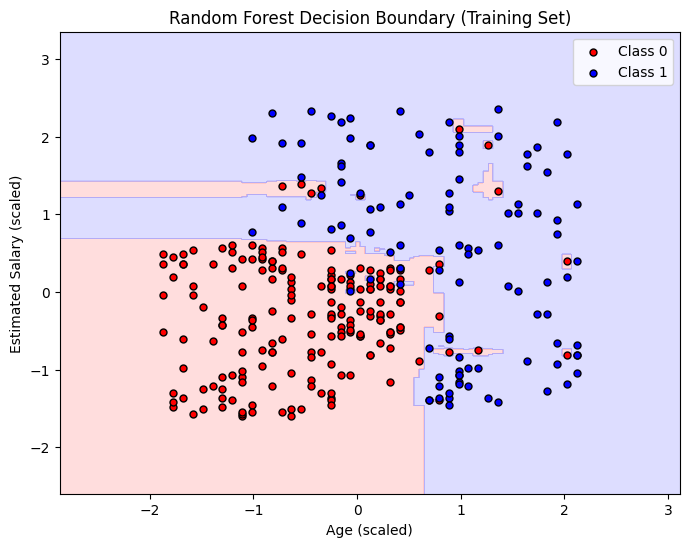

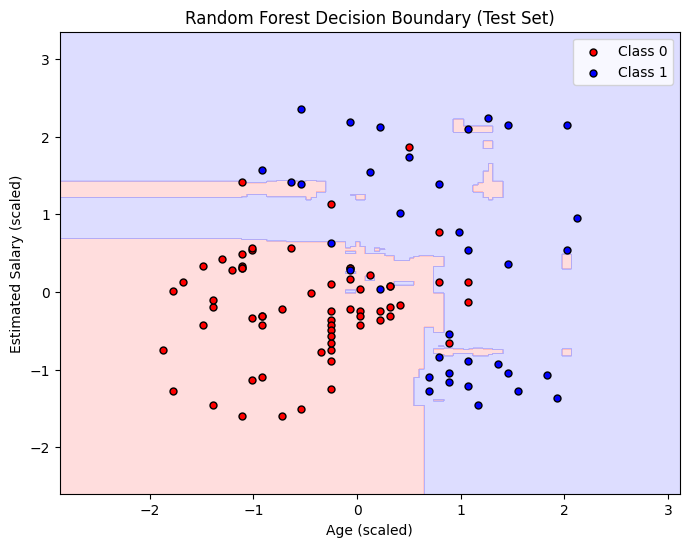

In [ ]:
def plot_decision_boundary(X, y, model, title):
    """Plot a classifier's decision boundary over scaled Age / EstimatedSalary features."""
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    cmap_background = ListedColormap(["#FFAAAA", "#AAAAFF"])
    cmap_points = ListedColormap(["#FF0000", "#0000FF"])

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_background)

    for cls in np.unique(y):
        mask = y == cls
        ax.scatter(X[mask, 0], X[mask, 1], c=[cmap_points(cls)], label=f"Class {cls}",
                   edgecolor="black", s=25)

    ax.set_title(title)
    ax.set_xlabel("Age (scaled)")
    ax.set_ylabel("Estimated Salary (scaled)")
    ax.legend()
    plt.show()


plot_decision_boundary(X_train, y_train, rf_model, "Random Forest Decision Boundary (Training Set)")
plot_decision_boundary(X_test, y_test, rf_model, "Random Forest Decision Boundary (Test Set)")

### Observations

# The decision boundary is blocky and jagged, which is typical of a Random Forest because it uses many tree splits.
# The training plot has a small red island inside the blue area. 
# It does not appear in the test plot, showing the model learned a few noisy training points (slight overfitting).
# The pattern is reasonable: low Age + low Salary and **high Age + high Salary are mostly predicted as Purchased (Class 1, blue).
# Most other areas are predicted as **Not Purchased (Class 0, red).
# Most test errors (8 false positives and 6 false negatives) are near the decision boundary, 
# meaning samples close to the boundary are the hardest to classify.



## Q2: k-Fold Cross-Validation Analysis

 k     mean      std      min      max
 3 0.893333 0.020548 0.870000 0.920000
 5 0.890000 0.040277 0.833333 0.950000
 7 0.876760 0.049091 0.813953 0.953488
10 0.900000 0.039441 0.866667 0.966667
15 0.900000 0.051640 0.800000 1.000000
20 0.906667 0.064636 0.800000 1.000000


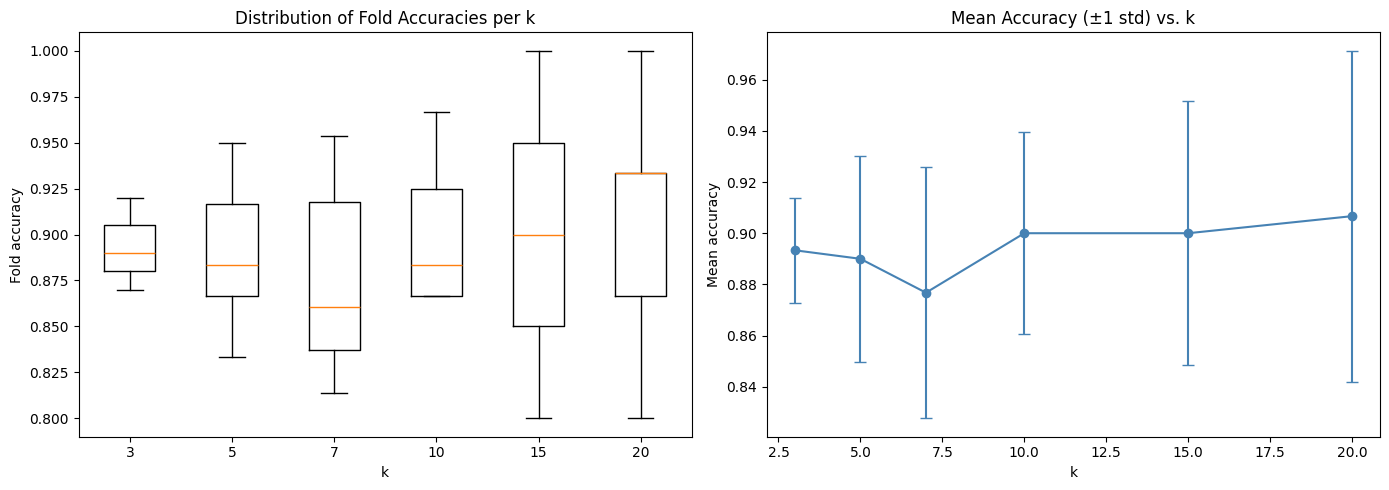

In [ ]:
def kfold_experiment(X_train, y_train, model, k_values):
    """Run cross_val_score for each k and summarize/plot the fold-accuracy distributions."""
    results = []
    fold_scores_by_k = []

    for k in k_values:
        scores = cross_val_score(model, X_train, y_train, cv=k, scoring="accuracy")
        fold_scores_by_k.append(scores)
        results.append({
            "k": k,
            "mean": scores.mean(),
            "std": scores.std(),
            "min": scores.min(),
            "max": scores.max(),
        })

    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].boxplot(fold_scores_by_k, tick_labels=k_values)
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Fold accuracy")
    axes[0].set_title("Distribution of Fold Accuracies per k")

    axes[1].errorbar(results_df["k"], results_df["mean"], yerr=results_df["std"],
                      marker="o", capsize=4, color="steelblue")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Mean accuracy")
    axes[1].set_title("Mean Accuracy (±1 std) vs. k")

    plt.tight_layout()
    plt.show()

    # Discussion: k=10 gives the most reliable result. It balances the training and test data well, so the accuracy is more stable. 
    # A small k (like 3) gives more variation between folds, making the results less consistent. 
    # A very large k (like 20) uses very small test sets, which can make the accuracy noisier and less reliable.


    return results_df


kfold_results = kfold_experiment(X_train, y_train, RandomForestClassifier(n_estimators=100, random_state=0),
                                  [3, 5, 7, 10, 15, 20])


                 Method     mean      std
RepeatedStratifiedKFold 0.899333 0.052277
          RepeatedKFold 0.894667 0.038505


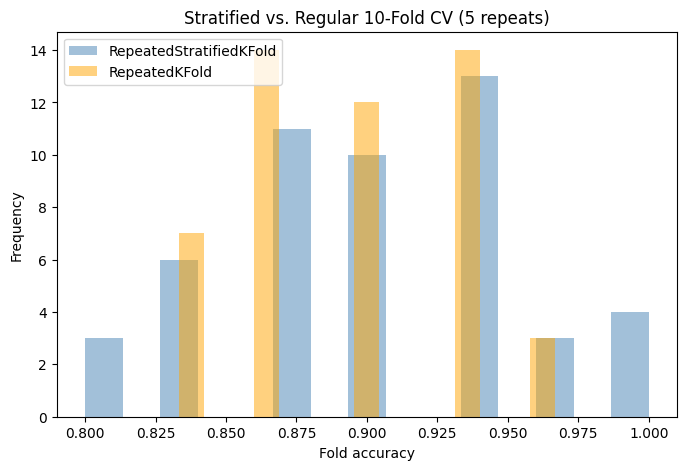

In [ ]:
def stratified_vs_regular(X_train, y_train, model, k=10, n_repeats=5):
    """Compare RepeatedStratifiedKFold vs. RepeatedKFold fold-accuracy distributions."""
    rskf = RepeatedStratifiedKFold(n_splits=k, n_repeats=n_repeats, random_state=0)
    rkf = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=0)

    stratified_scores = cross_val_score(model, X_train, y_train, cv=rskf, scoring="accuracy")
    regular_scores = cross_val_score(model, X_train, y_train, cv=rkf, scoring="accuracy")

    comparison_df = pd.DataFrame([
        {"Method": "RepeatedStratifiedKFold", "mean": stratified_scores.mean(), "std": stratified_scores.std()},
        {"Method": "RepeatedKFold", "mean": regular_scores.mean(), "std": regular_scores.std()},
    ])
    print(comparison_df.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(stratified_scores, bins=15, alpha=0.5, label="RepeatedStratifiedKFold", color="steelblue")
    ax.hist(regular_scores, bins=15, alpha=0.5, label="RepeatedKFold", color="orange")
    ax.set_xlabel("Fold accuracy")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Stratified vs. Regular {k}-Fold CV ({n_repeats} repeats)")
    ax.legend()
    plt.show()

    # Discussion: This dataset is imbalanced (about 64% Class 0 and 36% Class 1), 
    # so Stratified K-Fold is a better choice because it keeps the same class ratio in every fold. 
    # Without it, some folds may have too many or too few samples from one class, making the accuracy less reliable. 
    # In this case, both methods gave similar results because the dataset was large enough and 
    # random shuffling kept the class ratio close by chance. Even so, Stratified K-Fold is the safer choice, 
    # especially for more imbalanced datasets or larger values of k.

    return comparison_df


stratified_comparison = stratified_vs_regular(X_train, y_train, RandomForestClassifier(n_estimators=100, random_state=0))


## Q3: Grid Search & Hyperparameter Tuning

In [7]:
def run_grid_search(X_train, y_train, param_grid, cv=10):
    """Run GridSearchCV over a RandomForestClassifier and print the results table."""
    grid_search = GridSearchCV(
        RandomForestClassifier(random_state=0), param_grid, cv=cv, scoring="accuracy"
    )
    grid_search.fit(X_train, y_train)

    print(f"Best params: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}\n")

    results_df = pd.DataFrame(grid_search.cv_results_)[
        ["params", "mean_test_score", "std_test_score", "rank_test_score"]
    ].sort_values("rank_test_score")
    print(results_df.to_string(index=False))

    return grid_search


param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
}
grid_search = run_grid_search(X_train, y_train, param_grid)


Best params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.9200

                                                           params  mean_test_score  std_test_score  rank_test_score
    {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}         0.920000        0.037118                1
    {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 200}         0.920000        0.037118                1
    {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}         0.920000        0.037118                1
    {'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100}         0.920000        0.037118                1
   {'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 100}         0.920000        0.037118                1
   {'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 200}         0.920000        0.037118                1
  {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}         0.920000        

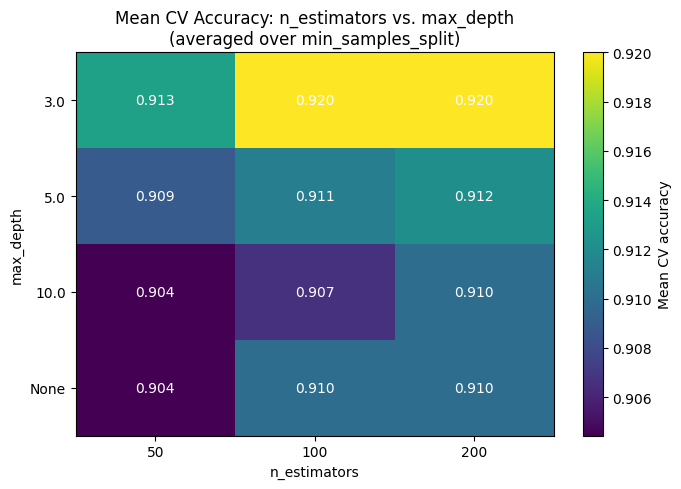

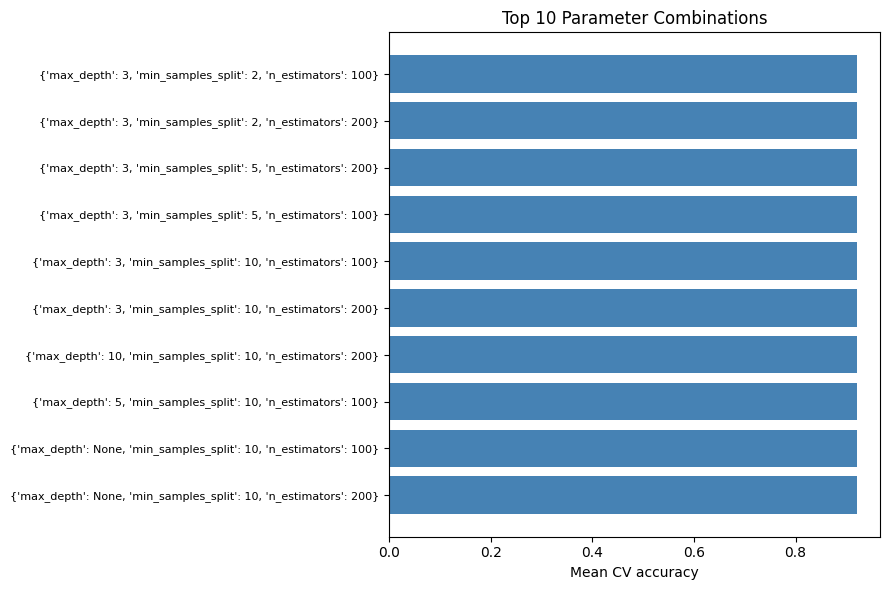

In [8]:
def visualize_grid_results(grid_search):
    """Heatmap of mean test accuracy (n_estimators vs. max_depth) plus top-10 params bar chart."""
    results_df = pd.DataFrame(grid_search.cv_results_)
    params_df = pd.json_normalize(results_df["params"])
    params_df["max_depth"] = params_df["max_depth"].astype(object).where(
        params_df["max_depth"].notna(), "None"
    )
    params_df["mean_test_score"] = results_df["mean_test_score"]

    pivot = params_df.pivot_table(
        index="max_depth", columns="n_estimators", values="mean_test_score", aggfunc="mean"
    )
    # Order rows so "None" (unlimited depth) sorts last instead of alphabetically/first.
    pivot = pivot.reindex(sorted(pivot.index, key=lambda v: (v == "None", v)))

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("max_depth")
    ax.set_title("Mean CV Accuracy: n_estimators vs. max_depth\n(averaged over min_samples_split)")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", color="white")

    fig.colorbar(im, ax=ax, label="Mean CV accuracy")
    plt.tight_layout()
    plt.show()

    top10 = results_df.sort_values("rank_test_score").head(10)
    labels = [str(p) for p in top10["params"]]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(range(len(top10)), top10["mean_test_score"], color="steelblue")
    ax.set_yticks(range(len(top10)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("Mean CV accuracy")
    ax.set_title("Top 10 Parameter Combinations")
    plt.tight_layout()
    plt.show()


visualize_grid_results(grid_search)


In [ ]:
def extended_grid_search(X_train, y_train, cv=10):
    """Run a wider GridSearchCV and compare it to the Q3(a) grid search result."""
    extended_param_grid = {
        "n_estimators": [50, 100, 200, 500],
        "max_depth": [3, 5, 10, 20, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
    }

    extended_grid_search_ = GridSearchCV(
        RandomForestClassifier(random_state=0), extended_param_grid, cv=cv,
        scoring="accuracy", n_jobs=-1,
    )
    extended_grid_search_.fit(X_train, y_train)

    print(f"Best params: {extended_grid_search_.best_params_}")
    print(f"Best CV score: {extended_grid_search_.best_score_:.4f}")
    print(f"\nQ3(a) grid search best CV score: {grid_search.best_score_:.4f}")
    print(f"Improvement: {extended_grid_search_.best_score_ - grid_search.best_score_:+.4f}")

#    Discussion: The larger search tested many more parameter combinations, so it took more time.
#    However, this dataset is small and has only two features, so the extra parameters made very little difference. 
#    The smaller search had already found a nearly optimal model. Any improvement is very small (less than 1%), 
#    so the extra computation is not worth it for this dataset. It is more useful for larger or more complex datasets.


    return extended_grid_search_


extended_search = extended_grid_search(X_train, y_train)


Best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 0.9200

Q3(a) grid search best CV score: 0.9200
Improvement: +0.0000


## Q4: Best Model Evaluation & Comparison

Best params: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}

Confusion matrix:
[[56  8]
 [ 3 33]]
Accuracy: 0.8900
Precision: 0.8049
Recall: 0.9167
F1-score: 0.8571

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91        64
           1       0.80      0.92      0.86        36

    accuracy                           0.89       100
   macro avg       0.88      0.90      0.88       100
weighted avg       0.90      0.89      0.89       100



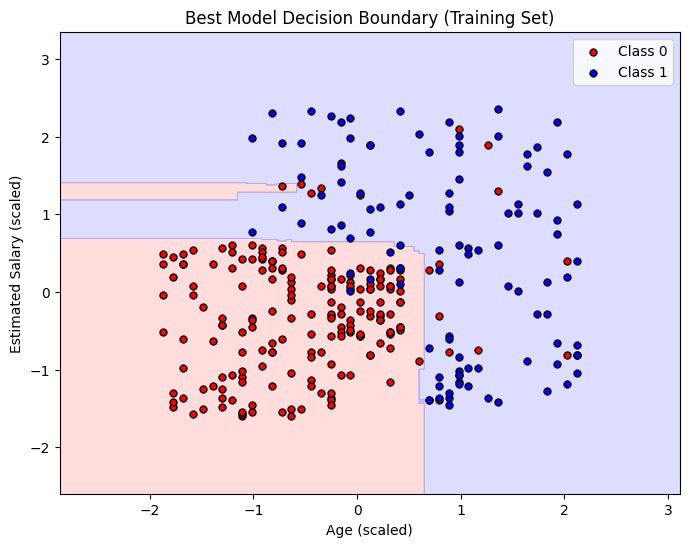

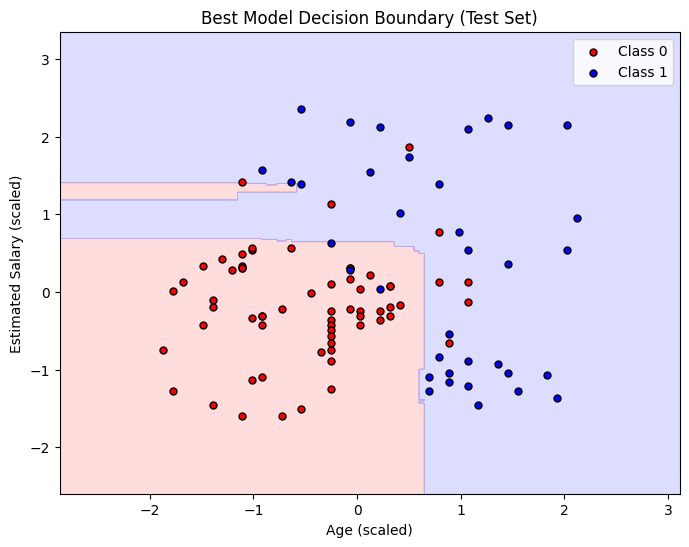


10-fold CV accuracy: mean=0.9200, std=0.0371
Test accuracy: 0.8900
Difference (test - CV mean): -0.0300


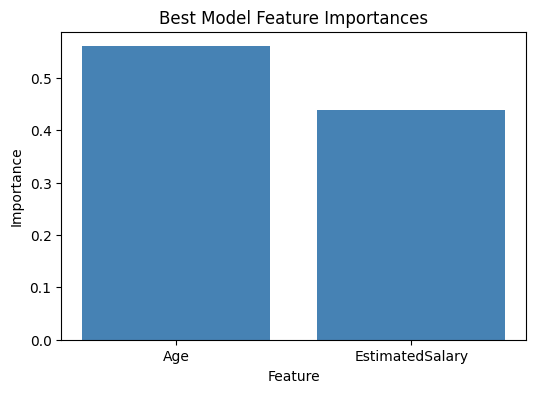

In [10]:
def evaluate_best_model(grid_search, X_train, X_test, y_train, y_test):
    """Evaluate the best GridSearchCV estimator: metrics, decision boundaries, CV vs. test, importances."""
    best_model = grid_search.best_estimator_

    y_pred = best_model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Best params: {grid_search.best_params_}\n")
    print(f"Confusion matrix:\n{cm}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}\n")
    print("Classification report:")
    print(classification_report(y_test, y_pred))

    plot_decision_boundary(X_train, y_train, best_model, "Best Model Decision Boundary (Training Set)")
    plot_decision_boundary(X_test, y_test, best_model, "Best Model Decision Boundary (Test Set)")

    cv_scores = cross_val_score(best_model, X_train, y_train, cv=10, scoring="accuracy")
    print(f"\n10-fold CV accuracy: mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Difference (test - CV mean): {acc - cv_scores.mean():+.4f}")

    feature_names = ["Age", "EstimatedSalary"]
    importances = best_model.feature_importances_

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(feature_names, importances, color="steelblue")
    ax.set_xlabel("Feature")
    ax.set_ylabel("Importance")
    ax.set_title("Best Model Feature Importances")
    plt.show()

    return best_model


best_model = evaluate_best_model(grid_search, X_train, X_test, y_train, y_test)


                 Classifier  Test Accuracy  CV Mean   CV Std
Random Forest (Grid Search)           0.89 0.920000 0.037118
        Logistic Regression           0.81 0.846667 0.037118
                  SVC (rbf)           0.89 0.916667 0.040139
                  KNN (k=5)           0.89 0.920000 0.040000


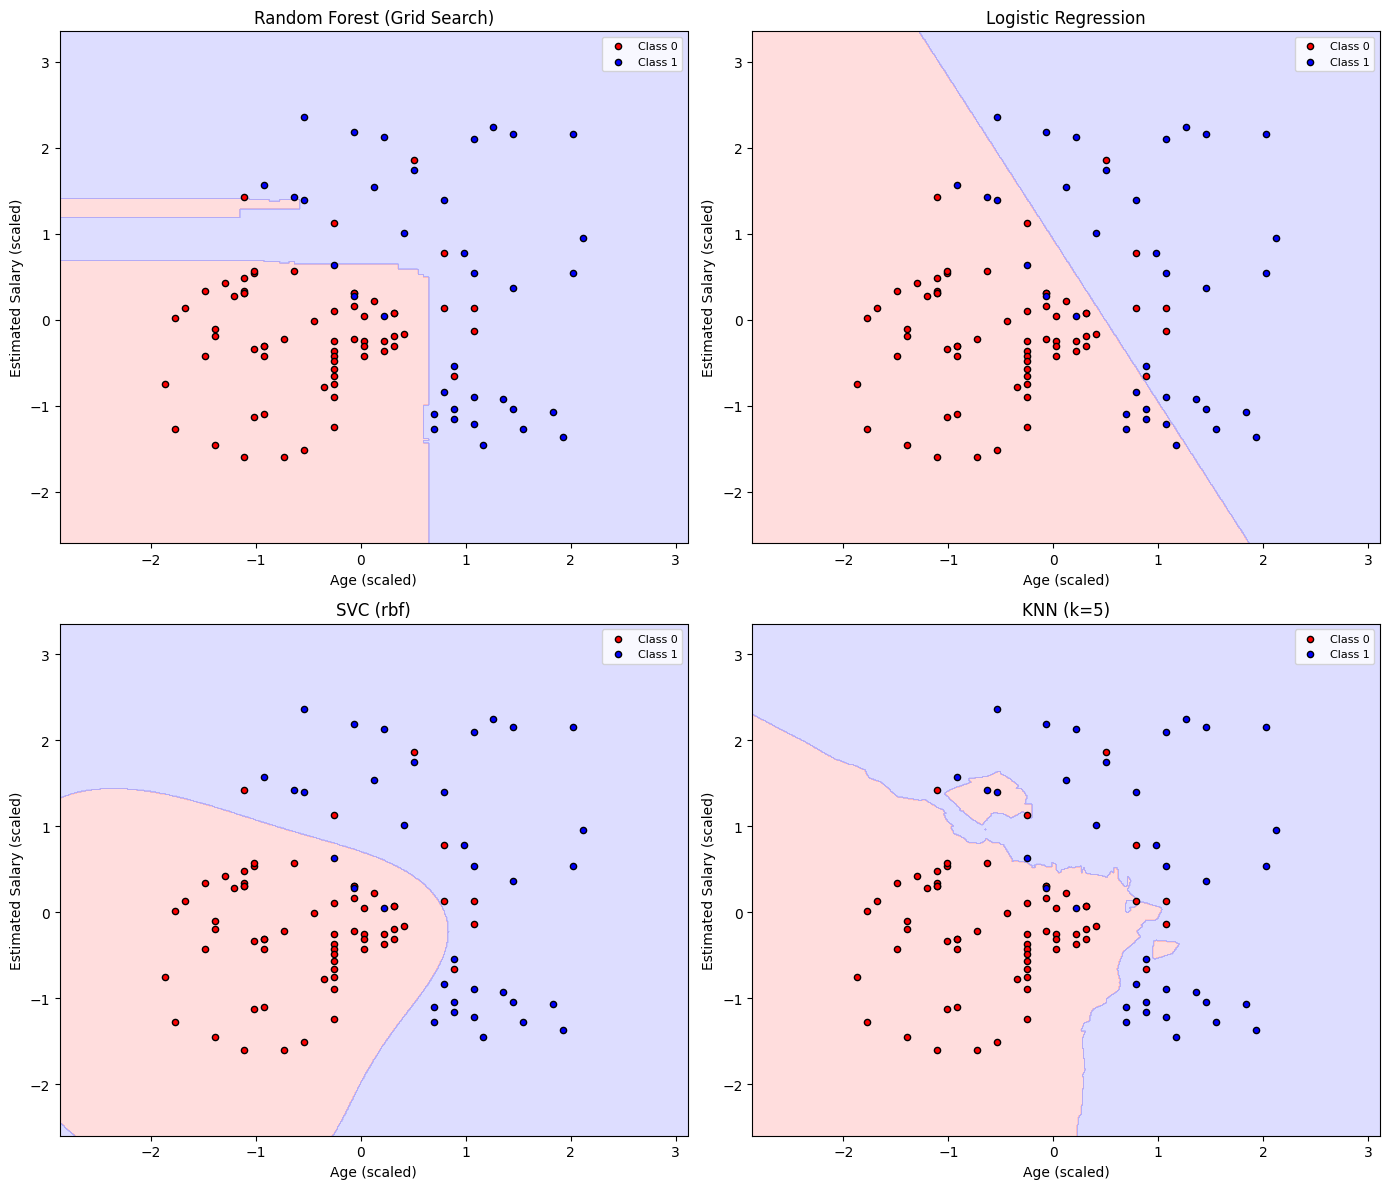

In [ ]:
def compare_classifiers(X_train, X_test, y_train, y_test):
    """Compare the best Random Forest against LogisticRegression, SVC, and KNN."""
    classifiers = {
        "Random Forest (Grid Search)": best_model,
        "Logistic Regression": LogisticRegression(random_state=0),
        "SVC (rbf)": SVC(kernel="rbf", random_state=0),
        "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    }

    rows = []
    fitted_models = {}
    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        fitted_models[name] = clf

        test_acc = accuracy_score(y_test, clf.predict(X_test))
        cv_scores = cross_val_score(clf, X_train, y_train, cv=10, scoring="accuracy")

        rows.append({
            "Classifier": name,
            "Test Accuracy": test_acc,
            "CV Mean": cv_scores.mean(),
            "CV Std": cv_scores.std(),
        })

    summary_df = pd.DataFrame(rows)
    print(summary_df.to_string(index=False))

    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    for ax, (name, clf) in zip(axes.ravel(), fitted_models.items()):
        x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
        y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
        Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

        cmap_background = ListedColormap(["#FFAAAA", "#AAAAFF"])
        cmap_points = ListedColormap(["#FF0000", "#0000FF"])

        ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_background)
        for cls in np.unique(y_test):
            mask = y_test == cls
            ax.scatter(X_test[mask, 0], X_test[mask, 1], c=[cmap_points(cls)],
                       label=f"Class {cls}", edgecolor="black", s=20)
        ax.set_title(name)
        ax.set_xlabel("Age (scaled)")
        ax.set_ylabel("Estimated Salary (scaled)")
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    # Discussion: On this small dataset with only two features (Age and Salary), 
    # simple models like Logistic Regression and SVC can perform almost as well as a tuned Random Forest. 
    # This is because the classes can be separated using a simple decision boundary, so a complex model is not needed.
    # A Random Forest builds many decision trees and combines their predictions. 
    # GridSearchCV tests many different parameter combinations (such as the number of trees and tree depth) to find the best model. 
    # This takes much more computation. If the final accuracy is only slightly better than the simpler models, 
    # the extra time is not worth it. GridSearchCV is more useful for larger datasets with many features 
    # and more complex patterns, where tuning the model can make a bigger difference.

    return summary_df


classifier_comparison = compare_classifiers(X_train, X_test, y_train, y_test)
